# RideMatch Colab Experiment Notebook

This notebook is the research surface for RideMatch. It generates synthetic fulfillment data, inspects the simulation, establishes the nearest-driver baseline, and provides a place to test improved ranking objectives.

The current `matched` label is generated by the nearest-driver policy. A model trained on it validates the pipeline but mostly learns to imitate that policy. Do not claim an ML improvement until policies are compared at the request level using wait, SLA, coverage, cancellation, and utilization metrics.

In [ ]:
# Colab setup. Skip the clone cell when running locally from the repository.
# !git clone https://github.com/sohan2000/ride-match-ml.git
# %cd ride-match-ml
# !pip install -r requirements.txt matplotlib

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NUM_DRIVERS = 40
NUM_RIDERS = 600
SIMULATION_STEPS = 1_440
SEED = 42

print(f"Repository: {REPO_ROOT.resolve()}")
print(f"Experiment: {NUM_DRIVERS} drivers, {NUM_RIDERS} requests, {SIMULATION_STEPS} minutes, seed {SEED}")

Repository: /Users/sohan/Downloads/ride-match-ml


In [ ]:
import pandas as pd
from pathlib import Path

from src.simulator.generate_data import generate_dataset

candidates = generate_dataset(
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)
Path("data/processed").mkdir(parents=True, exist_ok=True)
candidates.to_csv("data/processed/colab_candidates.csv", index=False)
candidates.head()

,event_time,request_id,driver_id,distance_km,eta_minutes,driver_idle_minutes,available_drivers,open_requests,hour_of_day,matched,realized_wait_minutes,cancelled,candidate_utility
0,2026-01-01T00:00:00+00:00,req-0000-00,d0,20.326,50.815,0.0,100,6,0,0,50.815,1,-170.934
1,2026-01-01T00:00:00+00:00,req-0000-00,d1,20.691,51.728,0.0,100,6,0,0,51.728,1,-174.222
2,2026-01-01T00:00:00+00:00,req-0000-00,d2,20.308,50.771,0.0,100,6,0,0,50.771,1,-170.775
3,2026-01-01T00:00:00+00:00,req-0000-00,d3,19.084,47.710,0.0,100,6,0,0,47.710,1,-159.754
4,2026-01-01T00:00:00+00:00,req-0000-00,d4,18.838,47.095,0.0,100,6,0,0,47.095,1,-157.543


In [3]:
print("Rows:", len(candidates))
print("Requests:", candidates["request_id"].nunique())
print("Candidate positive rate:", candidates["matched"].mean())
print("Candidates per request:")
print(candidates.groupby("request_id").size().describe())

display(candidates[[
    "distance_km",
    "eta_minutes",
    "driver_idle_minutes",
    "available_drivers",
    "open_requests",
    "hour_of_day",
]].describe())

Rows: 13287
Requests: 3358
Candidate positive rate: 0.25272823060133964
Candidates per request:
count    3358.000000
mean        3.956820
std         9.795659
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       100.000000
dtype: float64


,distance_km,eta_minutes,driver_idle_minutes,available_drivers,open_requests,hour_of_day
count,13287.000000,13287.000000,13287.000000,13287.000000,13287.000000,13287.000000
mean,11.482244,28.705603,28.765033,28.200120,6.567773,7.015203
std,5.280540,13.201355,24.690955,34.060031,3.664057,7.741568
min,0.087000,0.218000,0.000000,1.000000,1.000000,0.000000
25%,7.256000,18.140000,7.000000,3.000000,4.000000,0.000000
50%,11.589000,28.973000,23.000000,5.000000,6.000000,4.000000
75%,15.533500,38.833500,47.000000,59.000000,8.000000,14.000000
max,26.888000,67.219000,116.000000,100.000000,27.000000,23.000000


In [ ]:
from src.utils.metrics import marketplace_metrics
from src.simulator.generate_data import generate_outcomes

outcomes = generate_outcomes(
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)

baseline_metrics = marketplace_metrics(outcomes.to_dict("records"), sla_minutes=5.0)
pd.Series(baseline_metrics, name="nearest_driver_baseline")

requests                10000.00000
matched                 10000.00000
match_coverage              1.00000
average_wait_minutes       13.66468
p90_wait_minutes           26.99400
sla_hit_rate                0.02170
cancellation_rate           0.66420
driver_utilization          0.00000
Name: nearest_driver_baseline, dtype: float64

In [3]:
from src.models.train_model import train_and_evaluate

# This mirrors the production trainer and saves a portable joblib artifact.
model_metrics = train_and_evaluate(
    "data/processed/colab_candidates.csv",
    "models/colab_gbdt.pkl",
)
pd.Series(model_metrics, name="gbdt_validation")

roc_auc          0.906731
precision        0.819066
recall           0.747116
positive_rate    0.252728
Name: gbdt_validation, dtype: float64

In [6]:
from src.models.evaluate import evaluate_ranking_policy

ranking_report = evaluate_ranking_policy(
    "models/colab_gbdt.pkl",
    "data/processed/colab_candidates.csv",
    sla_minutes=5.0,
)
pd.Series(ranking_report, name="request_level_policy_comparison")

requests_with_candidates        3358.000000
model_ranking_accuracy             0.960393
model_average_eta_minutes         21.000602
baseline_average_eta_minutes      20.913283
eta_delta_minutes                  0.087320
model_sla_hit_rate                 0.064622
baseline_sla_hit_rate              0.064622
model_cancellation_proxy           0.935378
baseline_cancellation_proxy        0.935378
model_utilization_proxy            0.431976
baseline_utilization_proxy         0.430180
Name: request_level_policy_comparison, dtype: float64

In [4]:
from src.models.train_utility_model import train_utility_model

utility_metrics = train_utility_model(
    "data/processed/colab_candidates.csv",
    "models/colab_utility_gbdt.pkl",
)
print("Utility validation:")
pd.Series(utility_metrics)

Utility validation:


validation_mae    0.2518
dtype: float64

In [5]:
from src.models.tune_utility import tune_utility_weights

sweep = tune_utility_weights()
summary = (
    sweep.groupby(["idle_weight", "cancellation_weight"])
    .agg(
        mean_eta_delta=("eta_delta_minutes", "mean"),
        std_eta_delta=("eta_delta_minutes", "std"),
        mean_ranking=("model_ranking_accuracy", "mean"),
        mean_utilization=("model_utilization_proxy", "mean"),
        mean_cancellation=("model_cancellation_proxy", "mean"),
    )
    .reset_index()
    .sort_values(["mean_eta_delta", "std_eta_delta"])
)
summary.head(10)

,idle_weight,cancellation_weight,mean_eta_delta,std_eta_delta,mean_ranking,mean_utilization,mean_cancellation
2,0.00,12.0,0.000052,0.000127,0.998498,0.967656,0.94165
1,0.00,8.0,0.000106,0.000259,0.997748,0.967658,0.94165
0,0.00,4.0,0.000120,0.000269,0.996239,0.967658,0.94165
5,0.05,12.0,0.002681,0.004411,0.990676,0.967784,0.94165
4,0.05,8.0,0.004380,0.004999,0.985638,0.967859,0.94165
3,0.05,4.0,0.004741,0.004155,0.986399,0.967865,0.94165
8,0.10,12.0,0.004783,0.004177,0.986399,0.967866,0.94165
7,0.10,8.0,0.005356,0.005435,0.985587,0.967874,0.94165
6,0.10,4.0,0.011101,0.007263,0.978572,0.968121,0.94165


In [ ]:
from src.models.policy_eval import compare_policies

# Primary evaluation: replay both policies through the same driver state.
policy_results = compare_policies(
    "models/colab_utility_gbdt.pkl",
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)
policy_results

,policy,requests,matched,coverage,average_wait_minutes,p90_wait_minutes,sla_hit_rate,cancellation_rate,utilization
0,nearest,400,220,0.550,17.122408,36.0907,0.03,0.450,0.497794
1,model,400,222,0.555,17.281840,37.5867,0.03,0.445,0.511915


Matplotlib is building the font cache; this may take a moment.


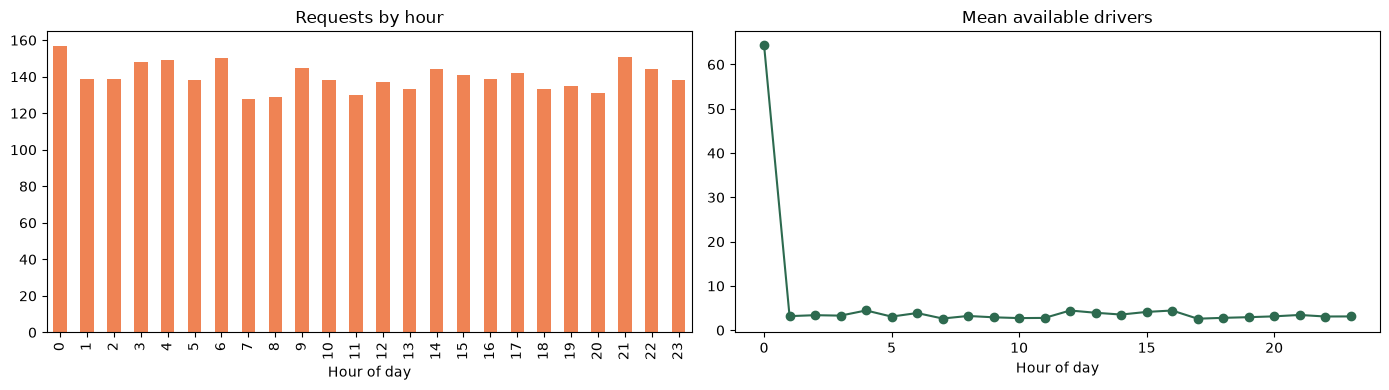

In [7]:
import matplotlib.pyplot as plt

# 1. Demand and supply over the simulated day.
demand_by_hour = candidates.groupby("hour_of_day")["request_id"].nunique()
supply_by_hour = candidates.groupby("hour_of_day")["available_drivers"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
demand_by_hour.plot(kind="bar", ax=axes[0], color="#ef8354", title="Requests by hour")
supply_by_hour.plot(kind="line", marker="o", ax=axes[1], color="#2d6a4f", title="Mean available drivers")
axes[0].set_xlabel("Hour of day")
axes[1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

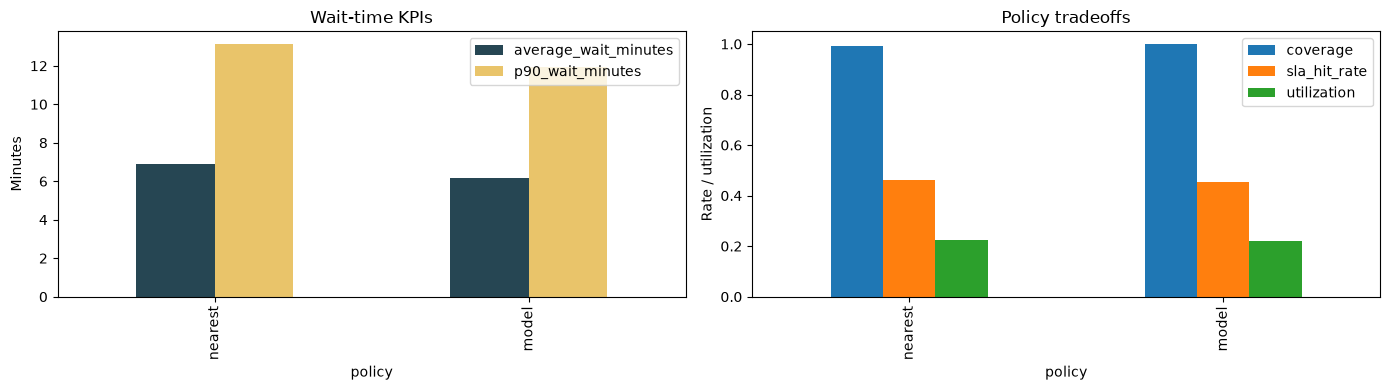

,policy,requests,matched,coverage,average_wait_minutes,p90_wait_minutes,sla_hit_rate,cancellation_rate,utilization
0,nearest,600,595,0.991667,6.909785,13.1342,0.461667,0.008333,0.224964
1,model,600,600,1.000000,6.175317,11.9591,0.453333,0.000000,0.219001


In [ ]:
# 2. Wait-time distribution for the baseline and learned policy.
from src.models.policy_eval import compare_policies

policy_results = compare_policies(
    "models/colab_utility_gbdt.pkl",
    num_drivers=NUM_DRIVERS,
    num_riders=NUM_RIDERS,
    steps=SIMULATION_STEPS,
    seed=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
policy_results.set_index("policy")[["average_wait_minutes", "p90_wait_minutes"]].plot(
    kind="bar", ax=axes[0], color=["#264653", "#e9c46a"], title="Wait-time KPIs"
)
policy_results.set_index("policy")[["coverage", "sla_hit_rate", "utilization"]].plot(
    kind="bar", ax=axes[1], title="Policy tradeoffs"
)
axes[0].set_ylabel("Minutes")
axes[1].set_ylabel("Rate / utilization")
plt.tight_layout()
plt.show()

policy_results

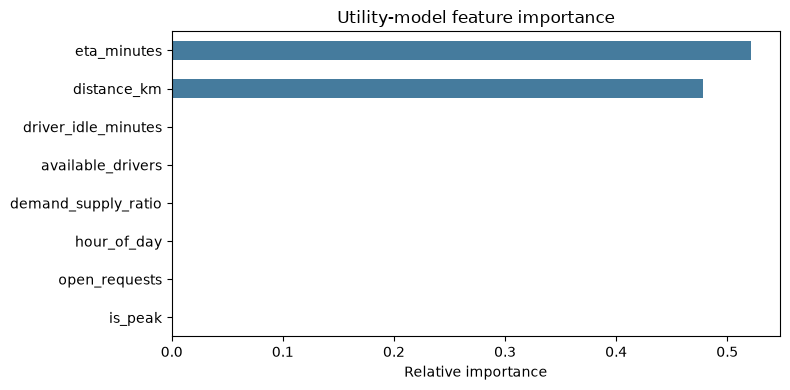

In [9]:
# 3. Inspect what the utility GBDT learned.
import joblib

utility_artifact = joblib.load("models/colab_utility_gbdt.pkl")
utility_model = utility_artifact["model"]
importance = pd.Series(
    utility_model.feature_importances_,
    index=utility_artifact["feature_columns"],
).sort_values()

importance.plot(kind="barh", figsize=(8, 4), color="#457b9d", title="Utility-model feature importance")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()

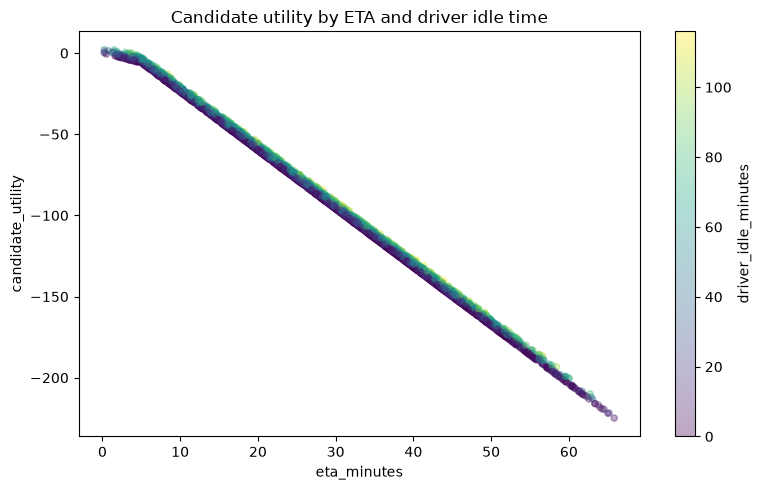

In [10]:
# 4. Visualize the synthetic utility landscape.
plot_data = candidates.sample(min(5_000, len(candidates)), random_state=42)
plot_data.plot.scatter(
    x="eta_minutes",
    y="candidate_utility",
    c="driver_idle_minutes",
    colormap="viridis",
    alpha=0.35,
    figsize=(8, 5),
    title="Candidate utility by ETA and driver idle time",
)
plt.tight_layout()
plt.show()

## Improved objective to implement next

The baseline label is policy-generated. For a meaningful ML experiment, add a delayed candidate utility or acceptance outcome that is not simply defined as nearest driver. Candidate selection should then be evaluated by replaying the policy over the same requests and comparing request-level KPIs.